# Plan

1. Mise en place
2. Mauvais exemple
3. Bon exemple
4. Comment personnaliser globalement le style des figures?
5. pandas + seaborn

# Mise en place

Nous commençons par importer les bibliothèques nécessaires.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

## Génération des données

Nous générons des données pour illustrer les différents concepts. Nous allons générer des données pour la vitesse d’un projectile en fonction de la pression.

In [2]:
def velocity(P, delta_x, friction_coeff=1.0):
    """
    Calculates velocity as a function of change in pressure (delta_P),
    change in distance (delta_x), mass (m), resistance coefficient (k),
    cross-sectional area (A), and pressure (P).

    Parameters:
    P (float): Change in pressure.
    delta_x (float): Change in distance.

    Returns:
    float: Calculated velocity.
    """
    A = 0.005
    m = 0.0027
    k = 5.95e-6 * friction_coeff
    P_base = 101.325

    numerator = 2 * (P - P_base) * 1e3 * A * delta_x
    denominator = m + k * A * delta_x * P * 1e3
    v = np.sqrt(numerator / denominator)
    return v

In [3]:
# Experimental data
np.random.seed(10)
x_data = np.arange(300.0, 405.0, 5.0)

velocities = velocity(x_data, 1.0, friction_coeff=5.0)
y_true_data = velocities
y_data = velocities + np.random.normal(loc=0, scale=1.5, size=x_data.shape)

In [4]:
print("Pressure : ", x_data)
print("Velocity : ", y_data)

Pressure :  [300. 305. 310. 315. 320. 325. 330. 335. 340. 345. 350. 355. 360. 365.
 370. 375. 380. 385. 390. 395. 400.]
Velocity :  [206.88999204 206.91655614 204.44340493 207.63536983 209.43657242
 208.25274589 210.53253017 211.07286476 211.66787226 212.12768755
 213.74511363 215.58495876 212.99742164 216.6327287  216.06007894
 216.99396543 215.21353554 217.69708241 220.28154417 216.98044511
 216.16462112]


# Mauvais exemple

Nous commençons par montrer un mauvais exemple de graphique. Le graphique n’est pas annoté et la légende n’est pas claire. En résumé, un graphique avec les paramètres par défaut et rien d’autre.

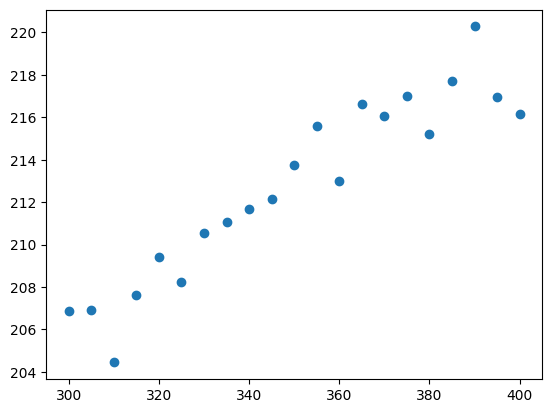

In [5]:
# Trace un nuage de point selon x_data et y_data
plt.scatter(x_data, y_data)
# Affiche la figure
plt.show()

Comme vous avez pu le constater, il était difficile de comprendre ce que vous regardiez. Essayons d’améliorer cela. Nous allons d’abord ajouter une légende au graphique. Il est important de noter qu’en général, vous verrez beaucoup de graphiques `matplotlib` utilisant un titre au lieu d’une légende, ne faites pas cela. Les graphiques avec titres sont utiles pour le débogage ou les présentations, pas pour un article scientifique. La légende est la bonne approche.

Remarque : ici, nous définissons une fonction pour générer la légende du graphique, mais en pratique vous utiliserez la commande `\caption{}` en LaTeX.

In [6]:
def caption(text, fig=None, **kwargs):
    if fig is None:
        fig = plt.gcf()
    caption_id = kwargs.pop("caption_id", 1)
    caption_type = kwargs.pop("caption_type", "Figure")
    fig.text(0.5, -0.05, f"{caption_type} {caption_id}: {text}", ha='center', **kwargs)

Nous allons maintenant ajouter une légende au graphique, mais une bonne question à se poser est : que doit contenir une légende ? Une légende doit contenir les informations suivantes :

- Le type de la figure (Figure, Tableau, etc.)
- Le numéro de la figure (normalement généré automatiquement par LaTeX)
- Une description claire et concise de la figure. On doit pouvoir comprendre la figure sans consulter le texte de l’article.
- Si la figure contient plusieurs sous-figures, la légende doit décrire chacune des sous-figures.
- Si la figure contient des acronymes, ils doivent être définis dans la légende.

Dans la cellule suivante, nous allons ajouter une légende au graphique et étiqueter les axes x et y. Nommez toujours vos axes et n’oubliez jamais les unités.

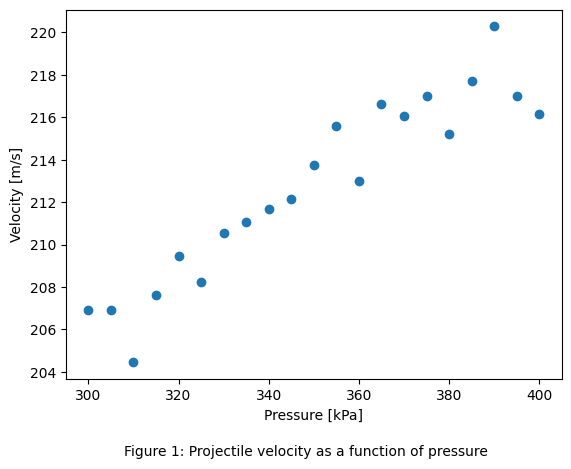

In [7]:
plt.scatter(x_data, y_data)
# Add a x label with the units
plt.xlabel("Pressure [kPa]")
# Add a y label with the units
plt.ylabel("Velocity [m/s]")
# Add a caption to the plot with the number of the figure, normally generated in latex
caption("Projectile velocity as a function of pressure")
plt.show()

Maintenant, supposons que nous connaissons le modèle théorique décrit par les données `y_true` et que nous savons que les données doivent être décrites par la fonction `velocity`. Nous pouvons ajuster le modèle aux données et le tracer. Nous utiliserons la fonction `curve_fit` de `scipy` pour effectuer l’ajustement. Nous tracerons ensuite les données et l’ajustement.

C’est un bon moyen de présenter l’écart entre vos données expérimentales et le modèle théorique. La comparaison entre le modèle théorique et les données expérimentales est toujours un excellent moyen de montrer la qualité de vos données.

In [21]:
# curve_fit
popt, pcov = curve_fit(f=velocity, xdata=x_data, ydata=y_data)
print(f"Parameters: {popt}")

Parameters: [2.91669554 5.16995263]


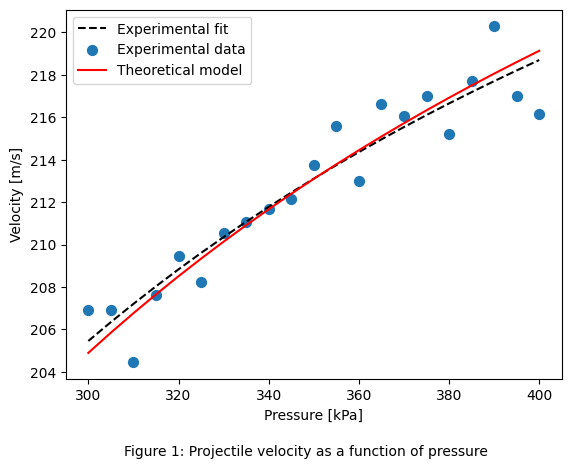

In [22]:
experimental_fit = velocity(x_data, *popt)

plt.plot(x_data, experimental_fit, color="black", linestyle="dashed", label="Experimental fit")
plt.scatter(x_data, y_data, s=50, label="Experimental data")
plt.plot(x_data, y_true_data, color="red", label="Theoretical model")
plt.legend()
plt.xlabel("Pressure [kPa]")
plt.ylabel("Velocity [m/s]")
caption("Projectile velocity as a function of pressure")
plt.show()

Maintenant, il est plus facile de voir que les données expérimentales suivent qualitativement les données théoriques. Cependant, il est difficile de juger dans quelle mesure les données suivent réellement le modèle théorique.

Nous pouvons ajouter l’équation de l’ajustement au graphique pour faciliter la compréhension, ou bien ajouter la valeur de R² pour montrer la qualité de l’ajustement. C’est ce que nous ferons dans la cellule suivante.

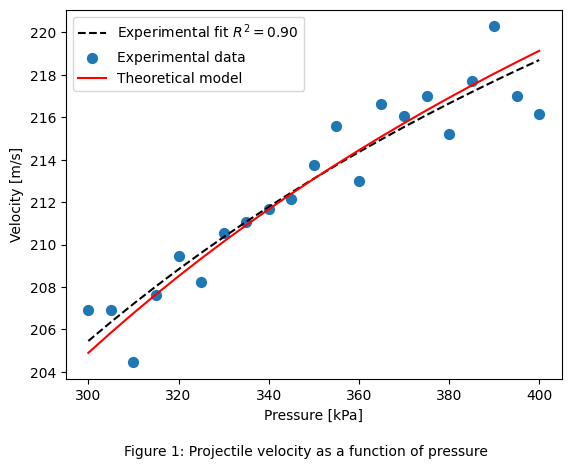

In [23]:
r_squared = 1 - np.sum((y_data - experimental_fit) ** 2) / np.sum((y_data - np.mean(y_data)) ** 2)

# Notice that we put the R² value in math mode, matplotlib will render it as a math equation, exactly as in latex
plt.plot(x_data, experimental_fit, color="black", linestyle="dashed", label=f"Experimental fit $R^2={r_squared:.2f}$")
plt.scatter(x_data, y_data, s=50, label="Experimental data")
plt.plot(x_data, y_true_data, color="red", label="Theoretical model")
plt.legend()
plt.xlabel("Pressure [kPa]")
plt.ylabel("Velocity [m/s]")
caption("Projectile velocity as a function of pressure")
plt.show()

# Bon example

Maintenant que nous avons toutes les informations sur le graphique, nous pouvons essayer d’améliorer son style. Une chose dont vous devez être sûr(e) est que les étiquettes, les graduations, la légende, … sont toutes suffisamment grandes pour que tout le monde puisse les lire facilement. Cela est encore plus important lorsque la figure est destinée à un article scientifique ou à une présentation.

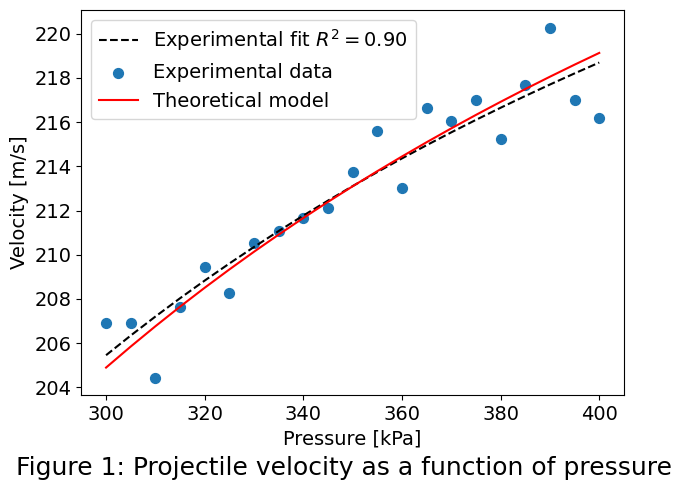

In [24]:
plt.figure(figsize=(7,5))
plt.plot(x_data, experimental_fit, color="black", linestyle="dashed", label=f"Experimental fit $R^2={r_squared:.2f}$")
plt.scatter(x_data, y_data, s=50, label="Experimental data")
plt.plot(x_data, y_true_data, color="red", label="Theoretical model")
plt.legend(fontsize=14)
plt.xlabel("Pressure [kPa]", fontsize=14)
plt.ylabel("Velocity [m/s]", fontsize=14)
caption("Projectile velocity as a function of pressure", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

Un autre détail important est de supprimer les espaces blancs excessifs. Par défaut, Matplotlib ajoute des marges sur les axes x et y, mais il est important d’optimiser l’espace, surtout pour les articles scientifiques où l’espace est limité.

En résumé, on a que:

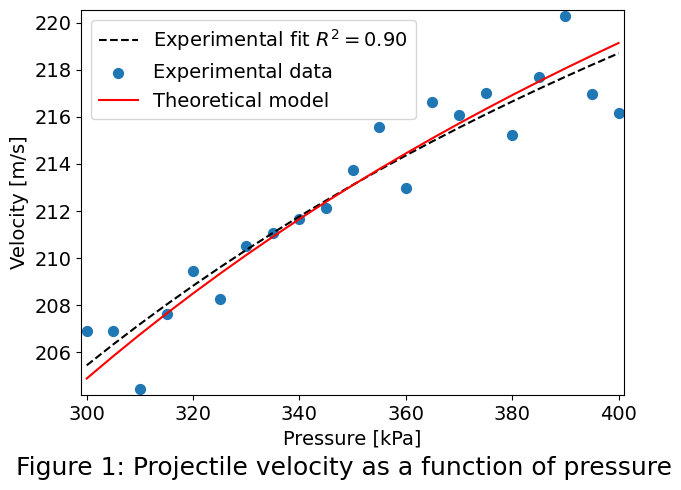

In [ ]:
plt.figure(figsize=(7,5))
plt.plot(x_data, experimental_fit, color="black", linestyle="dashed", label=f"Experimental fit $R^2={r_squared:.2f}$")
plt.scatter(x_data, y_data, s=50, label="Experimental data")
plt.plot(x_data, y_true_data, color="red", label="Theoretical model")
plt.legend(fontsize=14)
plt.xlabel("Pressure [kPa]", fontsize=14)
plt.ylabel("Velocity [m/s]", fontsize=14)
caption("Projectile velocity as a function of pressure", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlim(left=x_data.min() - 1,right=x_data.max() + 1) # Here we add +/- 1 to account for scatter width
plt.ylim(bottom=y_data.min() - 0.25,top=y_data.max() + 0.25)
plt.savefig("projectile_velocity_vs_pressure.pdf", bbox_inches='tight')
plt.show()

Vous devez ensuite enregistrer votre figure. Remarquez que la figure a été sauvegardée au format `.pdf`. Dans la mesure du possible, vous devriez toujours générer et enregistrer vos figures dans un format vectoriel, c’est-à-dire `.svg` ou `.pdf`. Cela permet de conserver la qualité de la figure en toutes circonstances.

Vous avez maintenant un graphique assez esthétique. Cependant, vous pouvez constater que nous avons dû modifier de nombreux paramètres pour qu’il ait cette apparence. C’est beaucoup de travail à refaire à chaque fois que vous tracez quelque chose. Dans la section suivante, nous verrons comment gérer le style de vos graphiques.

# Comment personnaliser globalement le style des figures?

Matplotlib possède de nombreux paramètres que vous pouvez modifier pour améliorer l’apparence de vos graphiques. Vous pouvez changer les paramètres par défaut de Matplotlib afin que vos graphiques soient déjà esthétiques sans avoir à modifier les paramètres à chaque tracé.

Vous pouvez modifier les paramètres par défaut de Matplotlib en utilisant la fonction `plt.rcParams.update()`. Vous pouvez également utiliser la fonction `mpl.style.use()` pour appliquer un style prédéfini. Il est aussi possible de créer votre propre style et de l’utiliser avec `mpl.style.use()`.

Nous verrons comment utiliser `rcParams` dans la cellule suivante.

### Utilisation des paramètres par défaut prédéfinis

Voici un dictionnaire de paramètres prédéfinis que vous pouvez utiliser pour améliorer l’apparence de vos graphiques. Vous pouvez modifier ces paramètres pour que vos graphiques aient l’apparence souhaitée. Vous pouvez également ajouter vos propres paramètres au dictionnaire.

In [15]:
MPL_RC_DEFAULT_PARAMS = {
    "figure.figsize": (8, 6),
    "font.size": 18,
    "legend.fontsize": 16,
    "lines.linewidth": 3.0,
    "lines.markersize": 10,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "font.family": "sans-serif",
    "font.sans-serif": [
        "Helvetica",
        "Nimbus Sans",
        "DejaVu Sans",
        "Arial",
        "Tahoma",
        "calibri",
    ],
}

Nous allons maintenant mettre à jour les paramètres par défaut de Matplotlib pour utiliser les paramètres prédéfinis. Nous tracerons ensuite à nouveau les données pour observer la différence.

In [16]:
plt.rcParams.update(MPL_RC_DEFAULT_PARAMS)

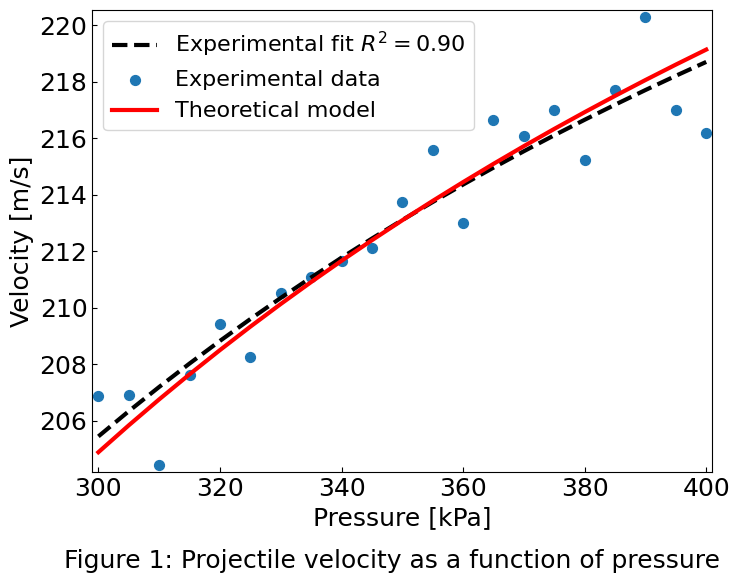

In [17]:
plt.plot(x_data, experimental_fit, color="black", linestyle="dashed", label=f"Experimental fit $R^2={r_squared:.2f}$")
plt.scatter(x_data, y_data, s=50, label="Experimental data")
plt.plot(x_data, y_true_data, color="red", label="Theoretical model")
plt.legend()
plt.xlabel("Pressure [kPa]")
plt.ylabel("Velocity [m/s]")
caption("Projectile velocity as a function of pressure")
plt.xlim(left=x_data.min() - 1,right=x_data.max() + 1) # Here we add +/- 1 to account for scatter width
plt.ylim(bottom=y_data.min() - 0.25,top=y_data.max() + 0.25)
plt.show()

# pandas + seaborn

Seaborn est une bibliothèque Python de visualisation de données construite sur Matplotlib.
Elle fournit une interface de haut niveau pour créer des graphiques statistiques attrayants et informatifs avec un minimum de code.

Seaborn fonctionne particulièrement bien avec les DataFrames de Pandas et est couramment utilisé pour l’analyse exploratoire des données.

In [ ]:
# Import Seaborn and Matplotlib
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
# Load a built-in dataset
df = sns.load_dataset("penguins")
df.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


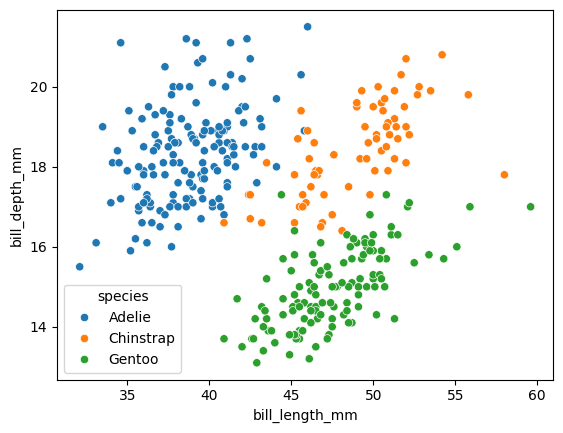

In [ ]:
# Example: Scatter plot with categorical coloring
sns.scatterplot(
    data=df,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="species"
)
plt.show() 
